In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

import joblib

In [5]:
df = pd.read_csv("../data/processed/creditcard_clean.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df["Log_Amount"] = np.log1p(df["Amount"])

In [7]:
df["Hour"] = (df["Time"] // 3600).astype(int)

In [8]:
df.drop(columns=["Amount"], inplace=True)

In [9]:
X = df.drop("Class", axis=1)

y = df["Class"]

In [10]:
print(X.shape)
print(y.shape)

(283726, 31)
(283726,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
print(X_train.shape)
print(X_test.shape)

(226980, 31)
(56746, 31)


In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [14]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X.columns
)

In [15]:
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

In [16]:
print(y_train.value_counts())

Class
0    226602
1       378
Name: count, dtype: int64


In [17]:
smote = SMOTE(
    sampling_strategy="auto",
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [18]:
print(y_train_smote.value_counts())

Class
0    226602
1    226602
Name: count, dtype: int64


In [19]:
X_train_scaled.to_csv(
    "../data/processed/X_train.csv",
    index=False
)

X_test_scaled.to_csv(
    "../data/processed/X_test.csv",
    index=False
)

y_train.to_csv(
    "../data/processed/y_train.csv",
    index=False
)

y_test.to_csv(
    "../data/processed/y_test.csv",
    index=False
)

X_train_smote.to_csv(
    "../data/processed/X_train_smote.csv",
    index=False
)

y_train_smote.to_csv(
    "../data/processed/y_train_smote.csv",
    index=False
)

In [20]:
print("Original Training Set :", X_train.shape)
print("Scaled Training Set   :", X_train_scaled.shape)
print("SMOTE Training Set    :", X_train_smote.shape)

print("Test Set              :", X_test_scaled.shape)

Original Training Set : (226980, 31)
Scaled Training Set   : (226980, 31)
SMOTE Training Set    : (453204, 31)
Test Set              : (56746, 31)


In [21]:
print(X_train_scaled.describe().loc[["mean", "std"]])

              Time            V1            V2            V3            V4  \
mean -1.518880e-16  1.627818e-18 -1.220864e-17  8.170396e-18 -2.657727e-17   
std   1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00   

                V5            V6            V7            V8            V9  \
mean  1.029908e-17 -1.139473e-17 -8.827784e-18 -1.095647e-19  7.763442e-18   
std   1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00   

      ...           V21           V22           V23           V24  \
mean  ...  2.504336e-18 -4.507805e-18  3.599983e-18 -6.933880e-18   
std   ...  1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00   

               V25           V26           V27           V28    Log_Amount  \
mean  3.944329e-18 -1.790600e-17  2.754770e-18  2.629553e-18  1.792635e-16   
std   1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00   

              Hour  
mean -1.079995e-16  
std   1.000002e+00  

[2 rows x 31 columns]


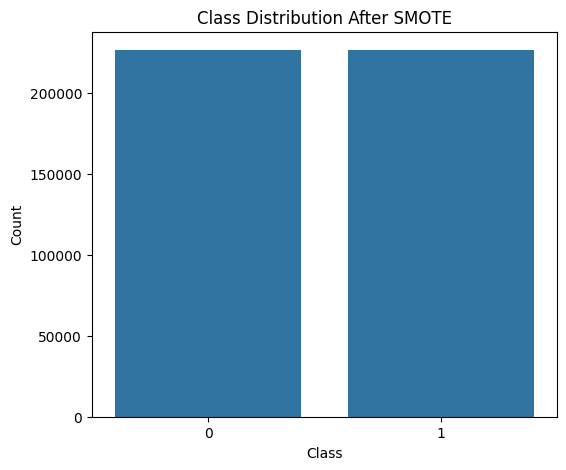

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.countplot(x=y_train_smote)

plt.title("Class Distribution After SMOTE")

plt.xlabel("Class")
plt.ylabel("Count")

plt.show()